## 📊 01. Exploratory Data Analysis (EDA)

이 노트북은 학습에 사용될 메인 데이터셋의 질환, 환자, 메타데이터 분포를 파악하는 목적으로 사용됩니다.

### 🎯 주요 분석 내용
- **Class Distribution 분석**: 14개 주요 흉부 질환의 발생 빈도, 클래스 불균형 정도 파악
- **Co-occurrence 분석**: 두 가지 이상의 질환이 동시에 나타나는 빈도 분석
- **Metadata 분석**: 성별, 연령대 분포 등 서브그룹 분석 전에 데이터 통계 점검


In [2]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.preprocess.split import patient_wise_split

# 1. 원본 정답지(CSV) 먼저 불러오기
csv_path = '../data/Data_Entry_2017.csv'
df = pd.read_csv(csv_path)

# 2. 85:15로 분리
train_df, _, test_df = patient_wise_split(
    df, 
    patient_col="Patient ID",
    val_ratio=0.0,            
    test_ratio=0.15,          
    seed=42                   
)

# 3. 결과 분석 (환자 수 vs 실제 이미지 장수 비율 확인)
total_imgs = len(train_df) + len(test_df)
train_img_ratio = (len(train_df) / total_imgs) * 100
test_img_ratio = (len(test_df) / total_imgs) * 100

print(f"\n--- 최종 이미지 장수 비율 검증 ---")
print(f"Train 이미지: {train_img_ratio:.2f}% ({len(train_df)}장)")
print(f"Test 이미지 : {test_img_ratio:.2f}% ({len(test_df)}장)")

Split (patient-wise) — train: 95992 imgs (26185 pts), val: 0 imgs (0 pts), test: 16128 imgs (4620 pts)

--- 최종 이미지 장수 비율 검증 ---
Train 이미지: 85.62% (95992장)
Test 이미지 : 14.38% (16128장)


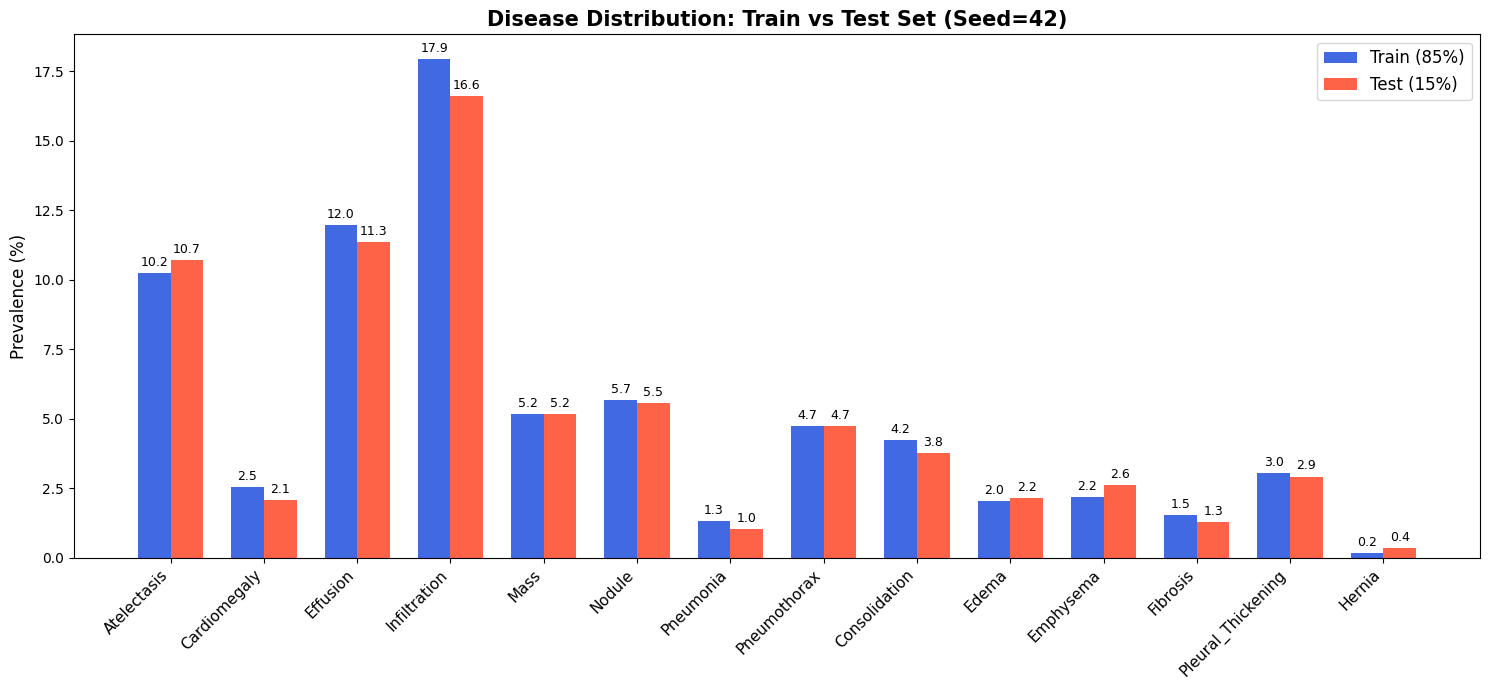

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 14개 주요 흉부 질환 리스트
DISEASE_LABELS = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# 2. 각 세트에서 질환별 발생 비율(%)을 계산하는 함수
def get_disease_ratio(df, labels):
    ratios = []
    total_imgs = len(df)
    for disease in labels:
        # 해당 질환 문자가 포함된 이미지 개수를 세고 비율 계산
        count = df['Finding Labels'].str.contains(disease, regex=False).sum()
        ratios.append((count / total_imgs) * 100)
    return ratios

# Train / Test 비율 계산
train_ratios = get_disease_ratio(train_df, DISEASE_LABELS)
test_ratios = get_disease_ratio(test_df, DISEASE_LABELS)

# 3. 그래프 그리기
x = np.arange(len(DISEASE_LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 7))
rects1 = ax.bar(x - width/2, train_ratios, width, label='Train (85%)', color='royalblue')
rects2 = ax.bar(x + width/2, test_ratios, width, label='Test (15%)', color='tomato')

ax.set_ylabel('Prevalence (%)', fontsize=12)
ax.set_title('Disease Distribution: Train vs Test Set (Seed=42)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DISEASE_LABELS, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)

ax.bar_label(rects1, fmt='%.1f', padding=3, size=9)
ax.bar_label(rects2, fmt='%.1f', padding=3, size=9)

plt.tight_layout()
plt.show()

전체 발견된 이미지 수: 112120장


밝기 계산 중:   0%|          | 0/1000 [00:00<?, ?it/s]

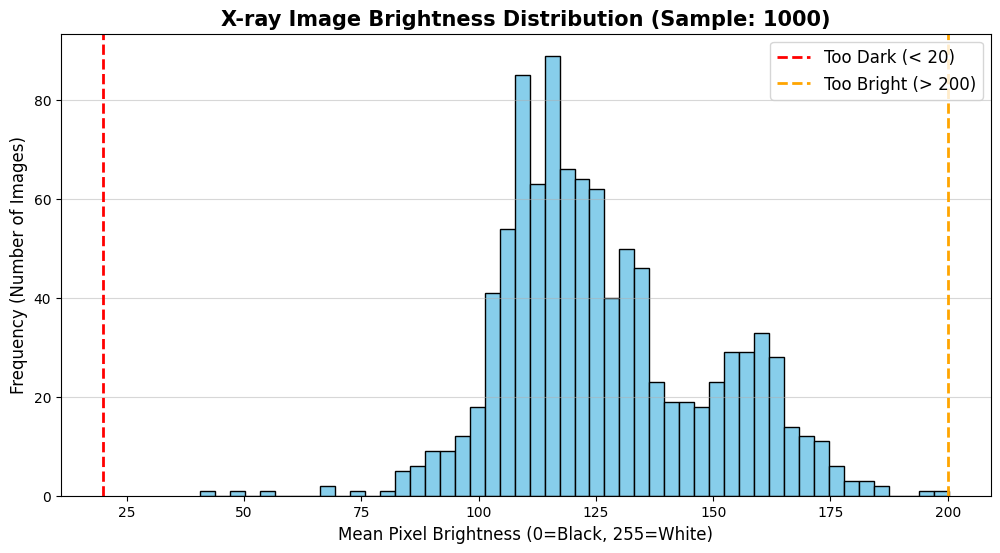

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

# 1. 전체 이미지 경로 스캔
all_image_paths = glob.glob('../data/**/*.png', recursive=True)
print(f"전체 발견된 이미지 수: {len(all_image_paths)}장")

if len(all_image_paths) == 0:
    print("🚨 이미지를 찾지 못했습니다. '../data/' 경로를 확인해 주세요!")
else:
    # 2. 1,000장 무작위 샘플링
    np.random.seed(42)
    sample_paths = np.random.choice(all_image_paths, 1000, replace=False)

    # 3. 이미지 평균 밝기 계산
    brightness_values = []
    
    for path in tqdm(sample_paths, desc="밝기 계산 중"):
        try:
            # 이미지를 흑백 모드('L')로 열고 numpy 배열로 변환
            img = Image.open(path).convert('L')
            img_array = np.array(img)
            
            # 픽셀들의 평균 밝기 값 계산 (0: 완전 검은색 ~ 255: 완전 흰색)
            mean_val = img_array.mean()
            brightness_values.append(mean_val)
        except Exception as e:
            print(f"Error reading {path}: {e}")

    # 4. 밝기 분포 히스토그램 그리기
    plt.figure(figsize=(12, 6))
    plt.hist(brightness_values, bins=50, color='skyblue', edgecolor='black')

    # 임시 임계값(Threshold) 선 긋기
    low_threshold = 20
    high_threshold = 200
    
    plt.axvline(x=low_threshold, color='red', linestyle='--', linewidth=2, label=f'Too Dark (< {low_threshold})')
    plt.axvline(x=high_threshold, color='orange', linestyle='--', linewidth=2, label=f'Too Bright (> {high_threshold})')

    plt.title('X-ray Image Brightness Distribution (Sample: 1000)', fontsize=15, fontweight='bold')
    plt.xlabel('Mean Pixel Brightness (0=Black, 255=White)', fontsize=12)
    plt.ylabel('Frequency (Number of Images)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(axis='y', alpha=0.5)
    plt.show()

새로운 기준(<70) 어두운 이미지 의심: 5장
새로운 기준(>200) 밝은 이미지 의심: 1장


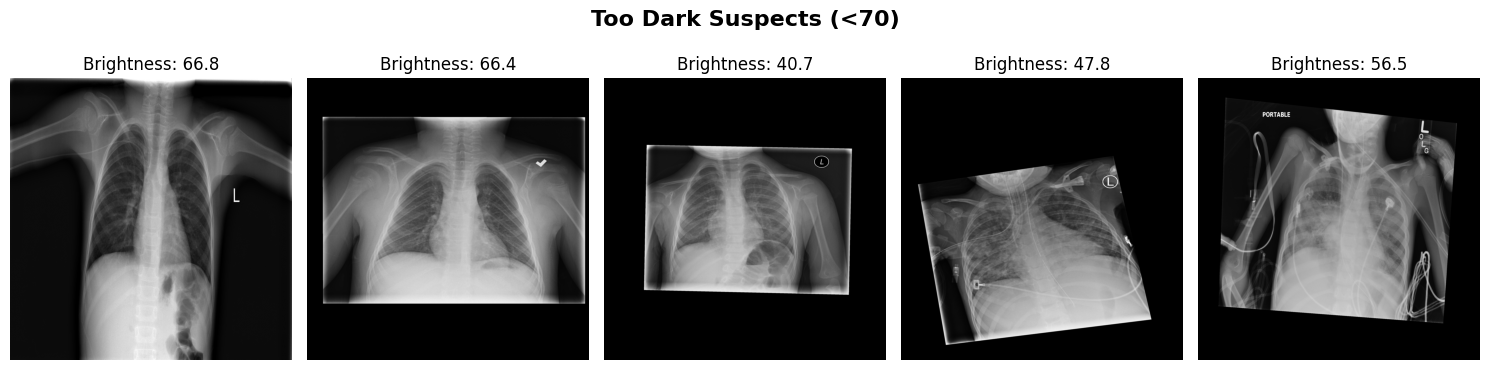

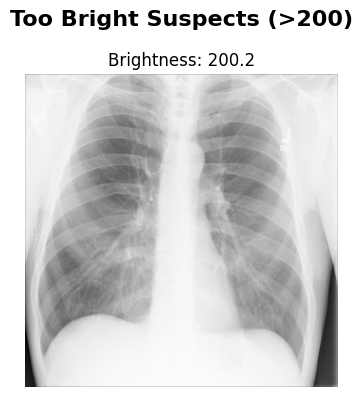

In [5]:
# 1. 새로운 기준으로 이미지 필터링 (70 이하, 200 이상)
low_threshold = 70
high_threshold = 200

dark_suspects = [path for path, b in zip(sample_paths, brightness_values) if b < low_threshold]
bright_suspects = [path for path, b in zip(sample_paths, brightness_values) if b > high_threshold]

print(f"새로운 기준(<{low_threshold}) 어두운 이미지 의심: {len(dark_suspects)}장")
print(f"새로운 기준(>{high_threshold}) 밝은 이미지 의심: {len(bright_suspects)}장")

# 2. 의심 이미지 시각화
def show_suspects(image_paths, title, max_display=5):
    if not image_paths:
        print(f"[{title}] 해당하는 이미지가 없습니다.")
        return
    
    display_count = min(len(image_paths), max_display)
    fig, axes = plt.subplots(1, display_count, figsize=(15, 4))
    
    # 이미지가 1장일 경우를 대비해 배열 형태로 통일
    if display_count == 1:
        axes = [axes]
        
    for ax, path in zip(axes, image_paths[:display_count]):
        img = Image.open(path).convert('L')
        img_array = np.array(img)
        mean_val = img_array.mean()
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Brightness: {mean_val:.1f}")
        ax.axis('off')
        
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 3. 화면에 출력
show_suspects(dark_suspects, "Too Dark Suspects (<70)")
show_suspects(bright_suspects, "Too Bright Suspects (>200)")

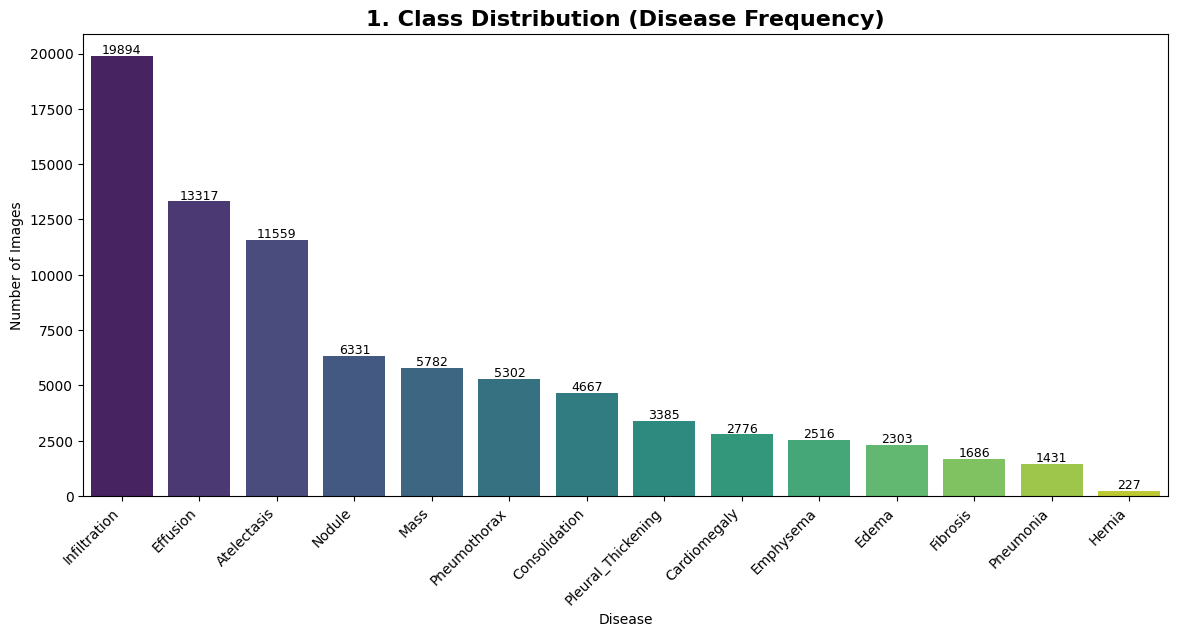

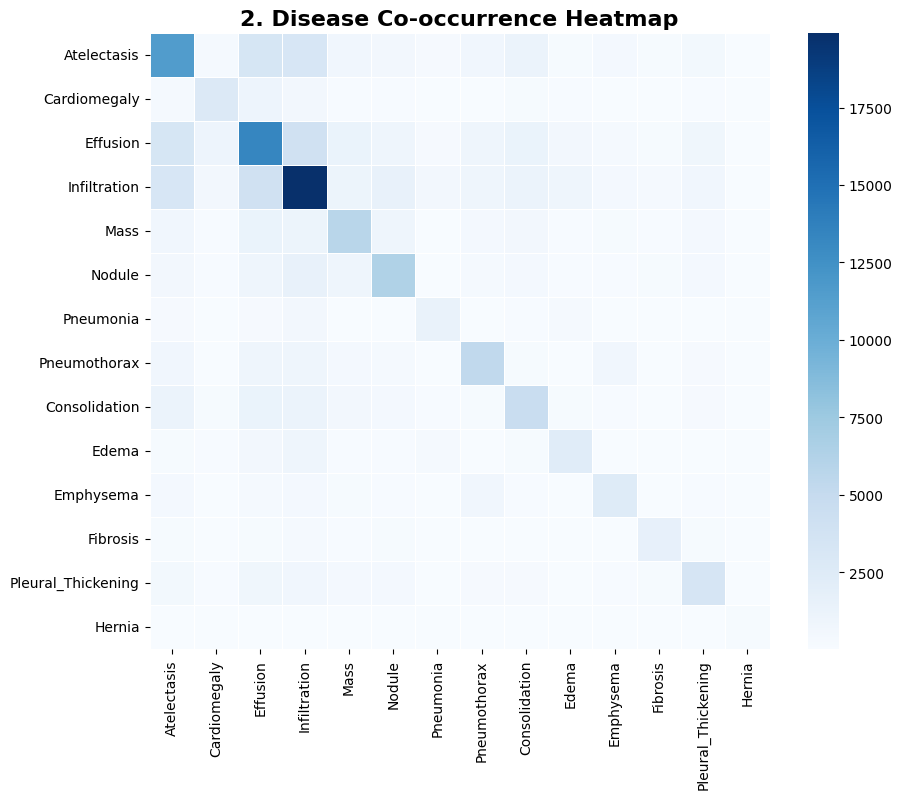

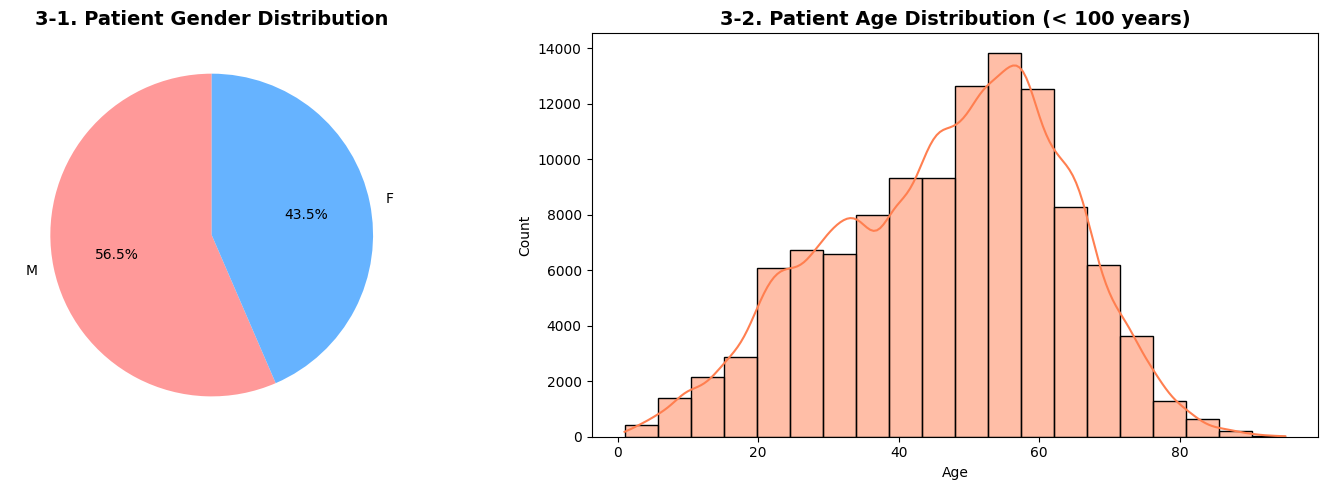

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 14개 주요 질환 리스트
DISEASE_LABELS = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

# ==========================================
# 1. Class Distribution (클래스 불균형 분석)
# ==========================================
plt.figure(figsize=(14, 6))
disease_counts = {disease: df['Finding Labels'].str.contains(disease).sum() for disease in DISEASE_LABELS}
disease_df = pd.DataFrame(list(disease_counts.items()), columns=['Disease', 'Count']).sort_values(by='Count', ascending=False)

sns.barplot(x='Disease', y='Count', data=disease_df, palette='viridis')
plt.title('1. Class Distribution (Disease Frequency)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Images')

# 막대 위에 숫자 표기
for i, v in enumerate(disease_df['Count']):
    plt.text(i, v + 100, str(v), ha='center', fontsize=9)
plt.show()

# ==========================================
# 2. Co-occurrence Matrix (동시 발생 분석)
# ==========================================
# 질환들을 0과 1로 원핫인코딩(One-Hot Encoding) 형태로 임시 변환
for disease in DISEASE_LABELS:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

# 질환 간의 상관관계(동시 발생) 매트릭스 계산
co_matrix = df[DISEASE_LABELS].T.dot(df[DISEASE_LABELS])

plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=False, cmap='Blues', linewidths=.5)
plt.title('2. Disease Co-occurrence Heatmap', fontsize=16, fontweight='bold')
plt.show()

# ==========================================
# 3. Metadata (성별 및 연령대 분포)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 성별 분포 (Pie Chart)
gender_counts = df['Patient Gender'].value_counts()
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
ax1.set_title('3-1. Patient Gender Distribution', fontsize=14, fontweight='bold')

# 연령대 분포 (Histogram)
# 나이가 100살이 넘는 이상치(기입 오류 등)가 있을 수 있으므로 100살 이하만 필터링
valid_ages = df[df['Patient Age'] < 100]['Patient Age']
sns.histplot(valid_ages, bins=20, kde=True, ax=ax2, color='coral')
ax2.set_title('3-2. Patient Age Distribution (< 100 years)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()